<!--
---
PURPOSE: Discover videos and align frame times to NWB timebase.
REQUIRES:
  - outputs/reports/session_inventory.parquet
PRODUCES:
  - outputs/video/video_assets.parquet
  - outputs/video/frame_times.parquet
WHAT_NEXT: notebooks/06_Pose_Estimation_Setup_SLEAP_or_DLC.ipynb
---
-->

# 05 Video I/O and Frame Timebase

**Purpose**
Discover videos and align frame times to NWB timebase.

**Requires**
- `outputs/reports/session_inventory.parquet`

**Produces**
- `outputs/video/video_assets.parquet`
- `outputs/video/frame_times.parquet`

**What to run next**
- `notebooks/06_Pose_Estimation_Setup_SLEAP_or_DLC.ipynb`

We locate videos, compute per-frame timestamps, and validate alignment.


## Environment Setup
We add the repo `src/` to the Python path so notebooks can import shared modules.

In [1]:
import sys
import importlib
import inspect
from pathlib import Path

# Resolve repo root whether notebook was launched from repo root or notebooks/.
ROOT = Path.cwd().resolve()
if (ROOT / "src").exists() and (ROOT / "notebooks").exists():
    pass
elif (ROOT.parent / "src").exists() and (ROOT.parent / "notebooks").exists():
    ROOT = ROOT.parent
else:
    raise RuntimeError(f"Could not resolve project root from cwd={Path.cwd()}")

SRC = ROOT / "src"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Ensure notebook uses the local io_sessions module from this repo.
io_sessions = importlib.import_module("io_sessions")
io_sessions = importlib.reload(io_sessions)
print("io_sessions:", io_sessions.__file__)
print("get_session_bundle:", inspect.signature(io_sessions.get_session_bundle))


io_sessions: /Users/muh/projects/vbn-analysis/src/io_sessions.py
get_session_bundle: (session_id: 'int', sessions_df: 'pd.DataFrame | None' = None, *, resolve_nwb: 'bool' = True, inspect_modalities: 'bool' = True) -> 'SessionBundle'


## Prerequisite Check
We parse the notebook header and validate required artifacts before running downstream steps.

In [2]:
from pathlib import Path
from reports import parse_notebook_header, validate_prerequisites

nb_path = ROOT / "notebooks" / "05_Video_IO_and_Frame_Timebase.ipynb"
header  = parse_notebook_header(nb_path)
missing = validate_prerequisites(header.get("REQUIRES", []))

if missing:
    print("Missing prerequisites:")
    for item in missing:
        print(" -", item)
else:
    print("All prerequisites satisfied.")

All prerequisites satisfied.


## Step 1: Build video manifest and frame times
This step enforces the timebase alignment tiers and produces QC flags.

  camera source  n_frames                              qc_flags
0    eye  local    575523  TIMESTAMP_NAN_PRESENT|DROPPED_FRAMES
1   face     s3    575522  TIMESTAMP_NAN_PRESENT|DROPPED_FRAMES
2   side  local    575525  TIMESTAMP_NAN_PRESENT|DROPPED_FRAMES
session_id=1055240613 camera='eye' frames=575523
frames_valid=575523 frames_est_total=575543 lost_est=20 lost_pct=0.003% fps_est=59.988 frame_idx_range=[1,575523]
largest_gaps(after->before, missing_est, gap_s):
  12->13  missing_est=20  gap_s=0.3500
session_id=1055240613 camera='face' frames=575522
frames_valid=575522 frames_est_total=575547 lost_est=25 lost_pct=0.004% fps_est=59.988 frame_idx_range=[1,575522]
largest_gaps(after->before, missing_est, gap_s):
  12->13  missing_est=25  gap_s=0.4333
session_id=1055240613 camera='side' frames=575525
frames_valid=575525 frames_est_total=575543 lost_est=18 lost_pct=0.003% fps_est=59.988 frame_idx_range=[1,575525]
largest_gaps(after->before, missing_est, gap_s):
  12->13  missing_est=18  ga

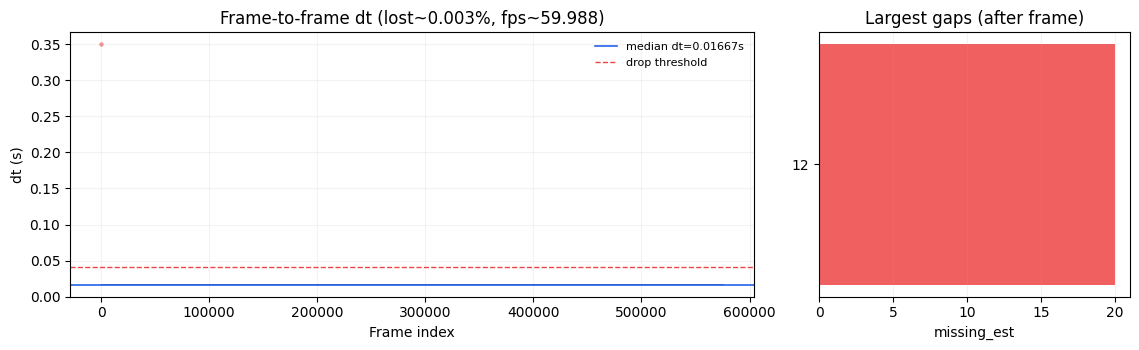

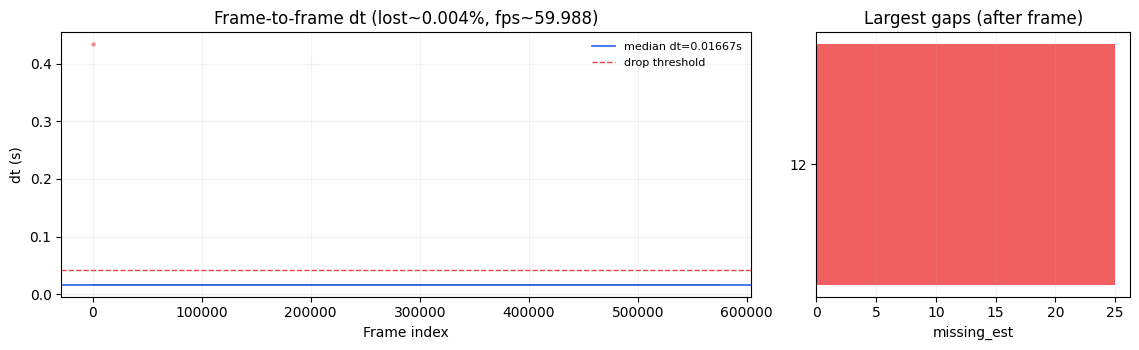

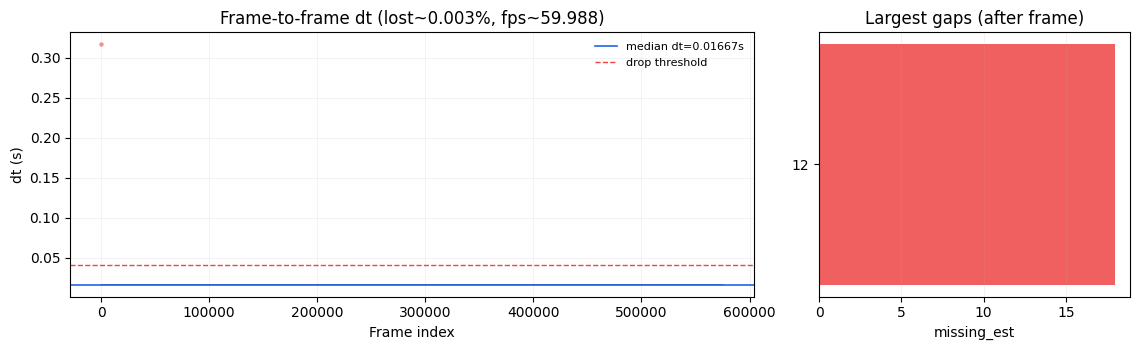

In [4]:
from io_sessions import load_sessions_csv, get_session_bundle
from viz import plot_video_alignment

sessions = load_sessions_csv()
SESSION_IDS = [1055240613]

for session_id in SESSION_IDS:
    bundle = get_session_bundle(session_id, sessions, resolve_nwb=False, inspect_modalities=False)
    assets = bundle.load_video_assets()
    frame_times = bundle.load_frame_times()
    if assets is not None and not assets.empty:
        print(assets[["camera", "source", "n_frames", "qc_flags"]])
    else:
        print("No video assets available.")
    if frame_times is not None and not frame_times.empty:
        for camera in sorted(frame_times["camera"].unique()):
            ft_cam = frame_times[frame_times["camera"] == camera]
            print(f"{session_id=} {camera=} frames={len(ft_cam)}")
            plot_video_alignment(ft_cam)
